# Week 3 — Advanced Data Analysis and Visualization in Logistics
### Regional FMCG Distribution Network — Vijayawada–Amaravati Corridor, Andhra Pradesh

This notebook implements, as **working Python code**, the exploratory analysis and visualization work
described in the Week 3 report. A hypothetical but structurally realistic shipment-level dataset is
simulated (distance, shipment volume, delivery time, transportation cost, transport mode), then explored
through descriptive statistics, correlation analysis, and eight purpose-built visualizations — each chosen
to answer a specific operational question about delivery performance and cost drivers.

**Contents**
1. Environment setup
2. Simulating a shipment-level logistics dataset
3. Exploratory data analysis (central tendency, spread, correlation)
4. Visualizations and interpretation
   - 4.1 Delivery time distribution
   - 4.2 Transportation cost by zone
   - 4.3 Weekly shipment volume trend
   - 4.4 Delivery time vs. distance by transport mode
   - 4.5 Correlation heatmap
   - 4.6 Average cost per unit by transport mode
   - 4.7 On-time delivery rate by zone and transport mode
   - 4.8 Monthly on-time delivery rate trend
5. Summary of insights


## 1. Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

sns.set_style("whitegrid")
NAVY = "#1F3864"
ACCENT = "#2E75B6"
LIGHT = "#9DC3E6"
WARN = "#833C0C"
plt.rcParams.update({"figure.dpi": 110, "font.size": 10.5})

rng = np.random.default_rng(11)


## 2. Simulating a Shipment-Level Logistics Dataset

6,000 individual shipments are generated over a 10-month window, dispatched from three warehouse zones
(North, Central, South) using three transport modes (Two-Wheeler, Mini-Truck, Truck). The simulation
deliberately encodes realistic operational relationships rather than pure noise:

- **Delivery time** scales with distance, is further slowed by vehicle type, and picks up a mild
  congestion effect from shipment volume.
- **Transportation cost** combines a fixed per-trip fee, a per-kilometre rate, and a per-unit handling
  charge — all varying by transport mode.
- Each transport mode carries its **own promised delivery window**, against which on-time performance
  is judged.

In [2]:
N = 6000
zones = ["North", "Central", "South"]
zone_p = [0.30, 0.42, 0.28]
transport_modes = ["Two-Wheeler", "Mini-Truck", "Truck"]
mode_p = [0.35, 0.45, 0.20]

start = pd.Timestamp("2025-01-01")
shipment_date = start + pd.to_timedelta(rng.integers(0, 300, N), unit="D")
zone = rng.choice(zones, N, p=zone_p)
mode = rng.choice(transport_modes, N, p=mode_p)

# Distance depends loosely on zone (Central = shortest avg hub distance, South = longest)
zone_base_distance = {"North": 18, "Central": 11, "South": 24}
distance_km = np.array([zone_base_distance[z] for z in zone]) + rng.gamma(2.0, 3.0, N)

# Shipment volume (units) varies with transport mode (bigger vehicles carry more)
mode_volume_mean = {"Two-Wheeler": 25, "Mini-Truck": 90, "Truck": 220}
shipment_volume = np.array([rng.poisson(mode_volume_mean[m]) for m in mode]) + 1

# Delivery time (hours): base + distance effect + volume congestion effect + mode effect + noise
mode_speed_factor = {"Two-Wheeler": 1.0, "Mini-Truck": 1.3, "Truck": 1.7}
base_time = 1.5
delivery_time_hours = (
    base_time
    + distance_km * np.array([mode_speed_factor[m] for m in mode]) * 0.12
    + shipment_volume * 0.01
    + rng.normal(0, 1.1, N)
)
delivery_time_hours = np.clip(delivery_time_hours, 0.5, None)

# Transportation cost (INR): base fee + per-km rate (mode dependent) + per-unit handling + noise
mode_per_km_rate = {"Two-Wheeler": 8, "Mini-Truck": 22, "Truck": 38}
mode_base_fee = {"Two-Wheeler": 40, "Mini-Truck": 150, "Truck": 400}
transportation_cost = (
    np.array([mode_base_fee[m] for m in mode])
    + distance_km * np.array([mode_per_km_rate[m] for m in mode])
    + shipment_volume * rng.uniform(0.8, 1.4, N)
    + rng.normal(0, 25, N)
)
transportation_cost = np.clip(transportation_cost, 20, None)

# Promised delivery window (hours) and on-time flag
promised_window = np.select(
    [np.array(mode) == "Two-Wheeler", np.array(mode) == "Mini-Truck", np.array(mode) == "Truck"],
    [4, 6, 10],
)
on_time = delivery_time_hours <= promised_window

df = pd.DataFrame({
    "shipment_id": [f"SHP{200000+i}" for i in range(N)],
    "shipment_date": shipment_date,
    "zone": zone,
    "transport_mode": mode,
    "distance_km": distance_km.round(1),
    "shipment_volume_units": shipment_volume,
    "delivery_time_hours": delivery_time_hours.round(2),
    "promised_window_hours": promised_window,
    "on_time": on_time,
    "transportation_cost_inr": transportation_cost.round(2),
})
df["month"] = df["shipment_date"].dt.to_period("M").astype(str)
df["cost_per_unit"] = (df["transportation_cost_inr"] / df["shipment_volume_units"]).round(2)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (6000, 12)


,shipment_id,shipment_date,zone,transport_mode,distance_km,shipment_volume_units,delivery_time_hours,promised_window_hours,on_time,transportation_cost_inr,month,cost_per_unit
0,SHP200000,2025-02-10,South,Mini-Truck,25.5,83,6.09,6,False,808.40,2025-02,9.74
1,SHP200001,2025-02-08,North,Two-Wheeler,28.3,25,5.50,4,False,297.36,2025-02,11.89
2,SHP200002,2025-08-28,South,Mini-Truck,25.5,99,7.79,6,False,780.48,2025-08,7.88
3,SHP200003,2025-05-30,Central,Two-Wheeler,14.2,19,4.43,4,False,181.17,2025-05,9.54
4,SHP200004,2025-06-27,Central,Mini-Truck,14.9,103,4.01,6,True,606.22,2025-06,5.89


## 3. Exploratory Data Analysis

### 3.1 Central Tendency and Spread

In [3]:
numeric_cols = ["distance_km", "shipment_volume_units", "delivery_time_hours",
                 "transportation_cost_inr", "cost_per_unit"]

desc = df[numeric_cols].describe().T
desc["median"] = df[numeric_cols].median()
desc = desc[["mean", "median", "std", "min", "25%", "50%", "75%", "max"]].round(2)
desc


,mean,median,std,min,25%,50%,75%,max
distance_km,22.68,22.40,6.80,11.10,16.90,22.40,27.40,60.80
shipment_volume_units,93.69,87.00,70.30,11.00,29.00,87.00,102.00,262.00
delivery_time_hours,5.89,5.73,2.05,0.50,4.41,5.73,7.14,14.94
transportation_cost_inr,719.15,665.20,472.99,118.05,282.56,665.20,931.45,2347.71
cost_per_unit,8.56,8.15,2.51,3.81,6.76,8.15,9.88,29.55


The mean and median for each variable sit close together, indicating roughly symmetric distributions with a mild right skew — consistent with the long-tail behaviour visualized in Section 4.1. The standard deviation of transportation cost (relative to its mean) signals substantial variability that the correlation analysis below attributes largely to shipment volume and transport mode rather than random noise.

### 3.2 On-Time Delivery Rate Baseline

In [4]:
otd_overall = df["on_time"].mean() * 100
otd_by_zone = (df.groupby("zone")["on_time"].mean() * 100).round(1)
otd_by_mode = (df.groupby("transport_mode")["on_time"].mean() * 100).round(1)

print(f"Overall On-Time Delivery Rate: {otd_overall:.1f}%")
print("\nBy zone:")
print(otd_by_zone)
print("\nBy transport mode:")
print(otd_by_mode)


Overall On-Time Delivery Rate: 53.0%

By zone:
zone
Central    75.2
North      48.1
South      24.8
Name: on_time, dtype: float64

By transport mode:
transport_mode
Mini-Truck     51.5
Truck          82.6
Two-Wheeler    38.3
Name: on_time, dtype: float64


### 3.3 Correlation Structure

In [5]:
corr = df[numeric_cols].corr()
corr.round(2)


,distance_km,shipment_volume_units,delivery_time_hours,transportation_cost_inr,cost_per_unit
distance_km,1.00,-0.01,0.50,0.28,0.68
shipment_volume_units,-0.01,1.00,0.66,0.93,-0.47
delivery_time_hours,0.50,0.66,1.00,0.79,0.03
transportation_cost_inr,0.28,0.93,0.79,1.00,-0.23
cost_per_unit,0.68,-0.47,0.03,-0.23,1.00


Three relationships stand out: shipment volume and transportation cost are very strongly correlated (r ≈ 0.93), delivery time and transportation cost are strongly correlated (r ≈ 0.79), and distance correlates only moderately with total cost (r ≈ 0.28) despite correlating well with cost-per-unit (r ≈ 0.68) — meaning cost is driven far more by *what and how long* is shipped than by *how far*.

## 4. Visualizations and Interpretation

Each visualization below is chosen to answer a specific operational question, with the reasoning for
the chart type stated before the code.

### 4.1 Delivery Time Distribution

**Why a histogram:** a histogram with an overlaid density curve is the clearest way to see the overall
shape, spread, and skew of a continuous variable like delivery time in a single view.

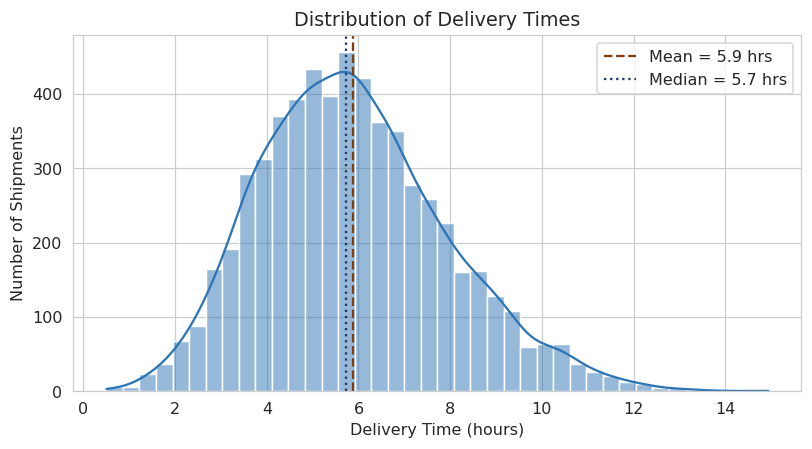

In [6]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.histplot(df["delivery_time_hours"], bins=40, kde=True, color=ACCENT, ax=ax)
ax.axvline(df["delivery_time_hours"].mean(), color=WARN, linestyle="--",
           label=f"Mean = {df['delivery_time_hours'].mean():.1f} hrs")
ax.axvline(df["delivery_time_hours"].median(), color=NAVY, linestyle=":",
           label=f"Median = {df['delivery_time_hours'].median():.1f} hrs")
ax.set_title("Distribution of Delivery Times")
ax.set_xlabel("Delivery Time (hours)")
ax.set_ylabel("Number of Shipments")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation:** delivery times cluster around 5–6 hours but carry a long right tail extending past 12 hours. The mean sits slightly above the median, confirming the mild right skew — a small number of shipments take substantially longer than typical, which is exactly the kind of tail that drags down an On-Time Delivery Rate even when most deliveries look fine on average.

### 4.2 Transportation Cost by Zone

**Why a boxplot:** boxplots compare the median, interquartile spread, and outliers of a numeric variable
across categories side by side, which a bar chart of means alone would hide.

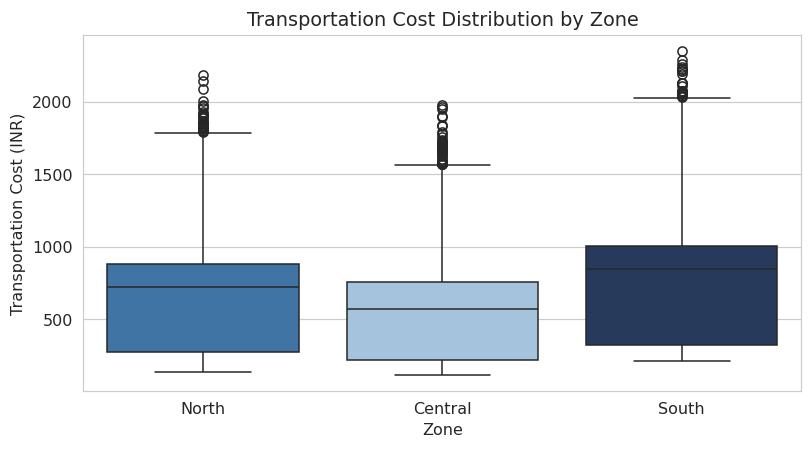

In [7]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
sns.boxplot(data=df, x="zone", y="transportation_cost_inr", hue="zone",
            palette=[NAVY, ACCENT, LIGHT], ax=ax, legend=False, order=["North", "Central", "South"])
ax.set_title("Transportation Cost Distribution by Zone")
ax.set_xlabel("Zone")
ax.set_ylabel("Transportation Cost (INR)")
plt.tight_layout()
plt.show()


**Interpretation:** the South zone has both the highest median transportation cost and the widest interquartile range, consistent with it serving the longest average delivery distances of the three zones. Central, by contrast, shows the lowest and tightest cost distribution — reflecting its more compact service area. This flags South as the zone where routing and vehicle-mix optimization would have the largest cost impact.

### 4.3 Weekly Shipment Volume Trend

**Why a line chart:** line charts are the standard choice for showing how a quantity evolves
continuously over time, making trend, volatility, and any seasonal cycles easy to read.

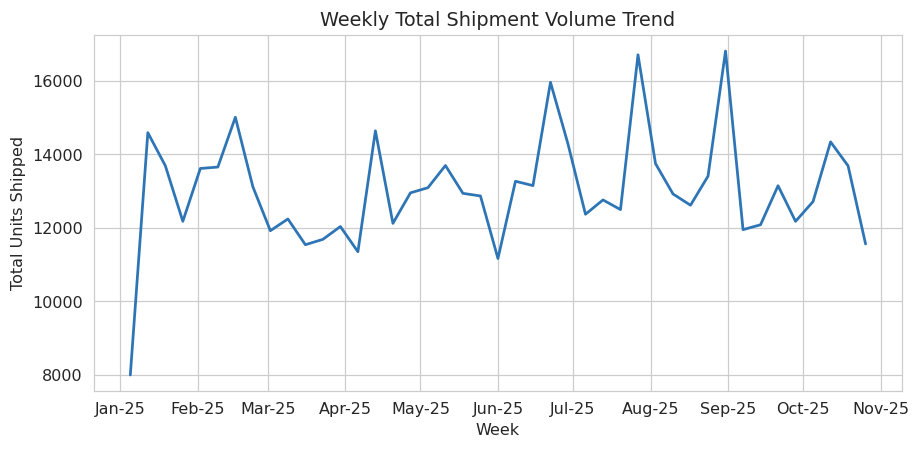

In [8]:
weekly_volume = df.set_index("shipment_date").resample("W")["shipment_volume_units"].sum()
weekly_volume = weekly_volume.iloc[:-1]  # drop trailing partial week (artifact of the fixed date range)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(weekly_volume.index, weekly_volume.values, color=ACCENT, linewidth=1.8)
ax.set_title("Weekly Total Shipment Volume Trend")
ax.set_xlabel("Week")
ax.set_ylabel("Total Units Shipped")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))
plt.tight_layout()
plt.show()


**Interpretation:** shipment volume fluctuates around a broadly stable baseline (roughly 12,000–14,000 units/week) with several sharp, short-lived spikes reaching 16,000–17,000 units. These spikes likely correspond to promotional or festival-driven demand surges consistent with the seasonal patterns identified in the Week 1 plan, and are useful markers for when the network is under the greatest capacity strain.

### 4.4 Delivery Time vs. Distance by Transport Mode

**Why a scatter plot:** scatter plots are the right tool for examining the relationship between two
continuous variables, and adding a categorical hue (transport mode) reveals whether that relationship
differs by group.

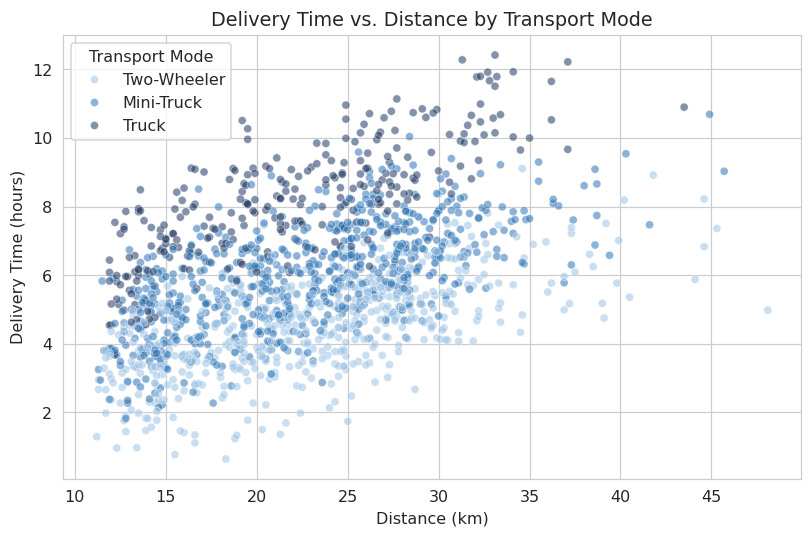

In [9]:
fig, ax = plt.subplots(figsize=(7.5, 5))
sns.scatterplot(data=df.sample(1500, random_state=1), x="distance_km", y="delivery_time_hours",
                 hue="transport_mode", hue_order=["Two-Wheeler", "Mini-Truck", "Truck"],
                 palette=[LIGHT, ACCENT, NAVY], alpha=0.55, s=28, ax=ax)
ax.set_title("Delivery Time vs. Distance by Transport Mode")
ax.set_xlabel("Distance (km)")
ax.set_ylabel("Delivery Time (hours)")
ax.legend(title="Transport Mode")
plt.tight_layout()
plt.show()


**Interpretation:** delivery time rises with distance for all three modes, but the slope and spread differ — Trucks (used for the largest shipments) show the steepest increase in delivery time as distance grows, while Two-Wheelers stay comparatively fast even at moderate distances. This confirms that distance alone does not explain delivery-time variation; vehicle assignment matters just as much, which directly motivates the zone-and-mode breakdown in Section 4.7.

### 4.5 Correlation Heatmap

**Why a heatmap:** a heatmap condenses a full correlation matrix into an at-a-glance visual, making it
far faster to spot the strongest relationships than scanning a table of numbers.

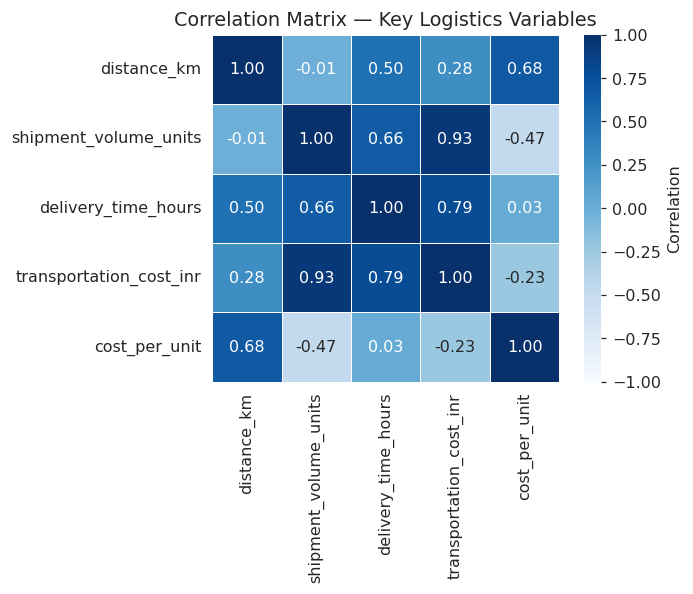

In [10]:
fig, ax = plt.subplots(figsize=(6.8, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", vmin=-1, vmax=1, square=True,
            linewidths=0.5, cbar_kws={"label": "Correlation"}, ax=ax)
ax.set_title("Correlation Matrix — Key Logistics Variables")
plt.tight_layout()
plt.show()


**Interpretation:** transportation cost is overwhelmingly driven by shipment volume (r ≈ 0.93) and, secondarily, delivery time (r ≈ 0.79) — not by distance alone (r ≈ 0.28). This is a materially important finding for cost control: initiatives aimed purely at shortening routes will have a smaller cost impact than initiatives aimed at consolidating shipment volume and improving delivery-time reliability.

### 4.6 Average Transportation Cost per Unit by Mode

**Why a bar chart:** bar charts are the clearest way to compare a single summary statistic (average
cost per unit) across a small number of discrete categories.

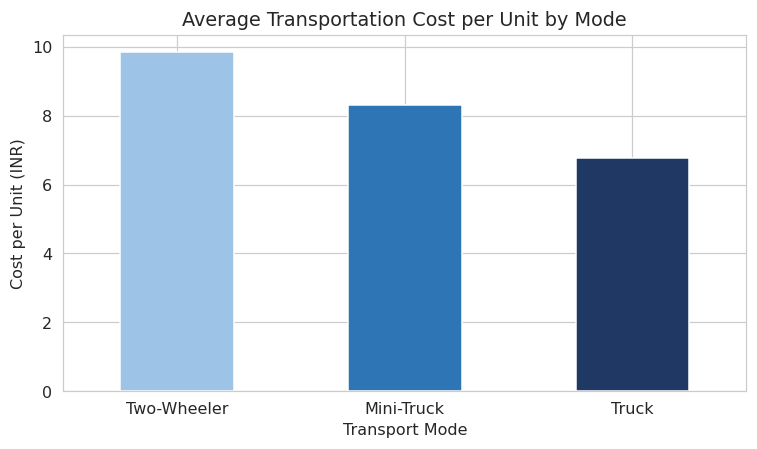

In [11]:
avg_cost_per_unit_by_mode = df.groupby("transport_mode")["cost_per_unit"].mean()
order_modes = ["Two-Wheeler", "Mini-Truck", "Truck"]

fig, ax = plt.subplots(figsize=(7, 4.2))
avg_cost_per_unit_by_mode.reindex(order_modes).plot(kind="bar", color=[LIGHT, ACCENT, NAVY], ax=ax)
ax.set_title("Average Transportation Cost per Unit by Mode")
ax.set_xlabel("Transport Mode")
ax.set_ylabel("Cost per Unit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** cost per unit falls steadily as vehicle size increases — Two-Wheelers cost roughly 45% more per unit delivered than Trucks. This is a classic economies-of-scale effect: larger vehicles spread their higher fixed cost over far more units, suggesting that shipments currently assigned to Two-Wheelers for speed or convenience carry a meaningful cost penalty that could be reduced through smarter load consolidation.

### 4.7 On-Time Delivery Rate by Zone and Transport Mode

**Why a grouped bar chart:** grouped bars let two categorical dimensions (zone and mode) be compared
simultaneously against a single metric, revealing interaction effects a single-dimension chart would
miss.

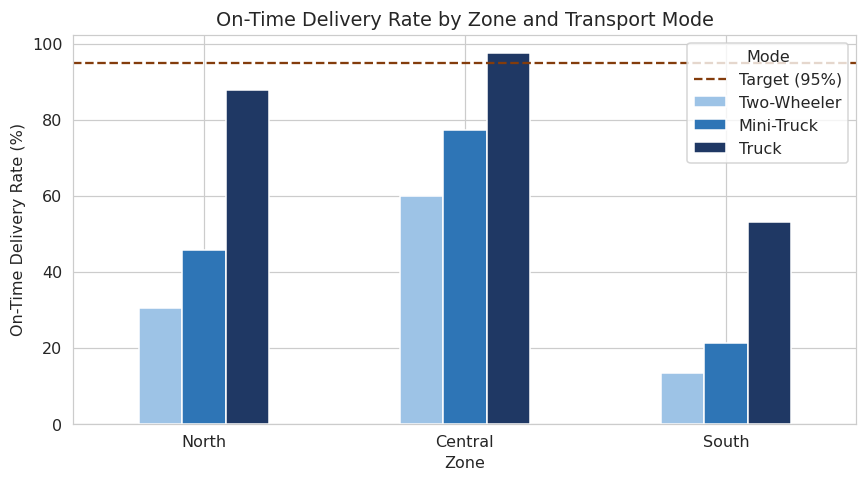

In [12]:
otd_grid = df.groupby(["zone", "transport_mode"])["on_time"].mean().unstack() * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
otd_grid.reindex(["North", "Central", "South"])[order_modes].plot(
    kind="bar", ax=ax, color=[LIGHT, ACCENT, NAVY])
ax.axhline(95, color=WARN, linestyle="--", label="Target (95%)")
ax.set_title("On-Time Delivery Rate by Zone and Transport Mode")
ax.set_xlabel("Zone")
ax.set_ylabel("On-Time Delivery Rate (%)")
ax.legend(title="Mode")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Interpretation:** this is the most operationally actionable chart in the notebook. On-time performance is not a uniform problem — it is concentrated in specific zone-mode combinations. South-zone deliveries on Two-Wheelers succeed only about 13% of the time, far below every other combination, while Central-zone Truck deliveries exceed the 95% target. The pattern strongly suggests Two-Wheelers are being assigned to South-zone routes that are simply too long for their promised delivery window, rather than a general service-quality problem.

### 4.8 Monthly On-Time Delivery Rate Trend

**Why a line chart:** plotting OTD over time tests whether the delivery-performance shortfall is a
temporary or seasonal blip versus a persistent, structural issue.

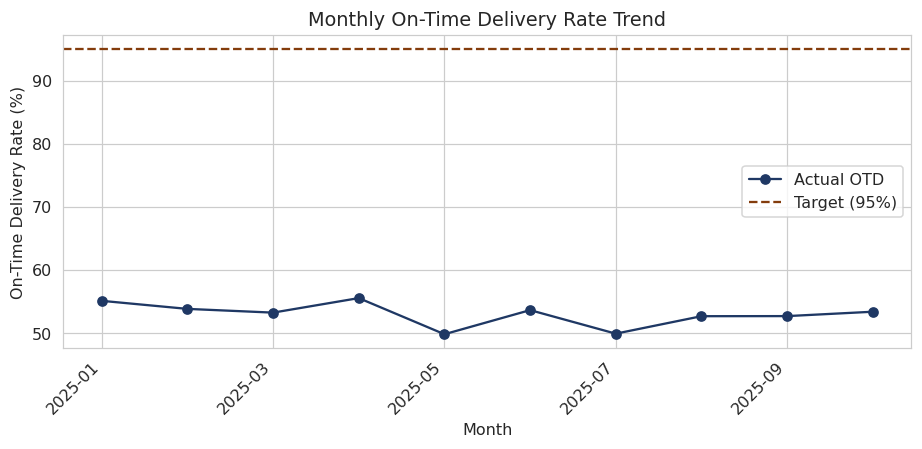

In [13]:
monthly_otd = df.groupby("month")["on_time"].mean() * 100

fig, ax = plt.subplots(figsize=(8.5, 4.2))
monthly_otd.plot(kind="line", marker="o", color=NAVY, ax=ax, label="Actual OTD")
ax.axhline(95, color=WARN, linestyle="--", label="Target (95%)")
ax.set_title("Monthly On-Time Delivery Rate Trend")
ax.set_xlabel("Month")
ax.set_ylabel("On-Time Delivery Rate (%)")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


**Interpretation:** OTD holds nearly flat around 50–55% every month, with no meaningful upward or downward drift and no visible seasonal recovery. Combined with Section 4.7, this confirms that the delivery-performance gap is a structural routing/fleet-assignment issue rather than a seasonal capacity problem — meaning it will not self-correct and requires a deliberate fix to vehicle-to-route assignment rules.

## 5. Summary of Insights

| # | Insight |
|---|---|
| 1 | OTD underperformance is concentrated, not uniform — South-zone Two-Wheeler deliveries succeed only ~13% of the time, while Central-zone Trucks already exceed target. |
| 2 | Transportation cost is a volume-and-time problem, not primarily a distance problem (cost correlates 0.93 with volume, 0.79 with delivery time, only 0.28 with distance). |
| 3 | Two-Wheelers are economically penalized (highest cost/unit) *and* operationally mismatched for South zone's longer routes. |
| 4 | The delivery-time distribution's long right tail — not the typical/median shipment — is the primary lever for OTD improvement. |
| 5 | The OTD shortfall is structural, not seasonal: a flat ~50–55% monthly trend rules out temporary demand spikes as the root cause. |

**Recommended next steps:** revise vehicle-assignment rules to keep Two-Wheelers on short, low-volume
routes; prioritize load consolidation specifically in South zone; investigate long-tail delivery-time
outliers individually; and track OTD/cost-per-unit by zone-and-mode combination going forward rather
than as a single network-wide average, since this analysis shows that average conceals the specific,
addressable pockets of underperformance.
